# Production-Ready Finance Research Agent

This notebook implements a professional-grade finance research agent for investment analysis. The agent is designed for high reliability, resilience, and demo-ready presentation.

## Key Features

- **Multi-Step Research Approach**: Breaks down complex investment questions into a detailed research plan with specific steps.
- **Adaptive Planning**: Dynamically adjusts research plans based on information gathered during execution.
- **Resilient Error Handling**: Robust error recovery at all stages of execution.
- **Timeout Management**: Enforces timeouts at multiple levels to prevent runaway processes and control API costs.
- **Production-Ready Logging**: Comprehensive logging for monitoring and debugging.
- **Input Validation**: Thorough validation and sanitization of user inputs.
- **Demo-Friendly Output**: Formatted, visual output suitable for client presentations.
- **Deterministic Behavior**: Consistent, predictable responses for the same inputs.

## Architecture

The agent employs a sophisticated architecture with these components:

1. **State Management**: Tracks research progress, errors, and timing information.
2. **Planning Component**: Creates a structured research plan tailored to the investment question.
3. **Execution Engine**: Systematically works through research steps using web search capabilities.
4. **Replanning Component**: Evaluates progress and determines whether to continue research or finalize an answer.
5. **Response Generation**: Synthesizes gathered information into a comprehensive investment analysis.

## Usage Notes

- This agent specializes in finance-related investment research questions.
- API keys for OpenAI and Tavily must be configured in the `.env` file.
- Typical runtime is 2-3 minutes for a complete analysis.
- Maximum execution time is capped at 3 minutes to control costs.
- The agent supports both synchronous and asynchronous execution patterns.

**IMPORTANT**: Investment recommendations are for demonstration purposes only. All output should be reviewed by financial professionals before making investment decisions.

# Environment Setup and API Integration

This cell performs several critical initialization steps:

1. **Environment Loading**: Loads API keys from the `.env` file using python-dotenv, which allows keeping credentials secure and separate from code.

2. **API Key Validation**: Checks that both required API keys (OpenAI and Tavily) are available, raising informative errors if they're missing.

3. **Base Libraries Setup**: Imports necessary modules and configures logging for better error tracking and debugging.

Note: The actual tools initialization and agent creation happen in subsequent cells after I define the custom tools for reliable operation.

In [71]:
# Load environment variables from .env file
import os
import time
import logging
import traceback
import asyncio
from dotenv import load_dotenv

# Set up logging
logging.basicConfig(level=logging.INFO, 
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger('Finance Agent')

# Load the .env file into environment variables
load_dotenv()

# Retrieve API keys from environment variables
openai_api_key = os.getenv("OPENAI_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

# Validate that required API keys are present
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found in environment variables or .env file")
if not tavily_api_key:
    raise ValueError("TAVILY_API_KEY not found in environment variables or .env file")

# Set the API keys in the environment to ensure they're accessible everywhere
os.environ["OPENAI_API_KEY"] = openai_api_key
os.environ["TAVILY_API_KEY"] = tavily_api_key

print("API keys loaded successfully!")

API keys loaded successfully!


# Local Evaluation System Setup

This cell sets up a comprehensive evaluation system for my finance research agent:

1. **Quality Metrics**: Defines finance-specific evaluation criteria to measure agent performance
2. **In-Memory Storage**: Creates a session storage mechanism to track evaluations
3. **Evaluation Logic**: Implements functions to assess agent responses using OpenAI's GPT-4o
4. **Rating System**: Establishes a weighted scoring system for detailed performance analysis

This local evaluation system replaces the need for external evaluation services while providing:
- Detailed performance metrics specific to finance research
- Visual dashboards for quality analysis
- Batch evaluation capabilities for systematic testing
- Runtime insights into agent operations

The metrics track both general quality dimensions (relevance, helpfulness) and finance-specific aspects like investment analysis quality and risk assessment depth.

In [72]:
# Import required libraries and setup the local evaluation system
import os
import time
from typing import Dict, List, Any, Optional

# Check for API keys
openai_api_key = os.getenv("OPENAI_API_KEY")
print(f"OpenAI API Key available: {'Yes' if openai_api_key else 'No'}")

# Set up a local evaluation system
local_eval_enabled = True
print("✅ Local evaluation system enabled")

# Finance-specific evaluation criteria
finance_eval_criteria = {
    # Response quality metrics
    "relevance": "How relevant the response is to the investment query",
    "helpfulness": "How helpful the response is for making an investment decision",
    "correctness": "Factual correctness of financial information and market analysis",
    "completeness": "Whether the response fully addresses all aspects of the investment query",
    
    # Process metrics
    "follows_instructions": "Whether the agent follows the prescribed research process",
    "reasoning_quality": "Quality of financial reasoning and investment analysis",
    
    # Finance-specific metrics
    "investment_analysis": "Thoroughness of investment opportunity analysis",
    "risk_assessment": "Quality of risk evaluation and discussion of potential downsides",
    "market_awareness": "Demonstration of awareness of current market conditions",
    "financial_literacy": "Proper use of financial terminology and concepts"
}

# Track evaluations in memory for this session
evaluation_history = []

# Function to log an evaluation locally
def log_evaluation(
    query: str, 
    response: str, 
    metadata: Optional[Dict[str, Any]] = None,
    past_steps: Optional[List[tuple]] = None
) -> str:
    """
    Log an evaluation to local storage
    
    Args:
        query: The user's original query
        response: The final response from the agent
        metadata: Additional metadata about the run
        past_steps: List of completed research steps and their results
        
    Returns:
        The evaluation ID
    """
    if not local_eval_enabled:
        return ""
    
    run_id = f"local-eval-{int(time.time())}"
    try:
        # Prepare metadata
        full_metadata = metadata or {}
        
        # Add the research steps as metadata
        if past_steps:
            steps_data = []
            for i, (step, result) in enumerate(past_steps):
                steps_data.append({
                    "step_number": i + 1,
                    "step_name": step,
                    "result": result
                })
            full_metadata["research_steps"] = steps_data
        
        # Create evaluation entry
        evaluation_entry = {
            "id": run_id,
            "timestamp": time.time(),
            "query": query,
            "response": response,
            "metadata": full_metadata
        }
        
        # Store in local history
        evaluation_history.append(evaluation_entry)
        
        print(f"✅ Evaluation logged locally with ID: {run_id}")
        
        return run_id
            
    except Exception as e:
        print(f"❌ Error logging evaluation: {str(e)}")
    
    return run_id

# The evaluation metrics we'll use to assess agent performance
evaluation_metrics = list(finance_eval_criteria.keys())

# Async function to evaluate a trace using GPT-4 through the OpenAI API
async def evaluate_response(run_id):
    """
    Evaluate a specific trace
    
    Args:
        run_id: The evaluation ID to evaluate
    
    Returns:
        Dictionary of evaluation scores
    """
    if not local_eval_enabled or not run_id:
        return {}
    
    try:
        from langchain_openai import ChatOpenAI
        
        print(f"Evaluating response: {run_id}")
        
        # Find the evaluation in history
        evaluation = next((e for e in evaluation_history if e["id"] == run_id), None)
        if not evaluation:
            print(f"❌ Evaluation with ID {run_id} not found")
            return {}
            
        # Get query and response
        query = evaluation["query"]
        response = evaluation["response"]
        
        # Initialize OpenAI client for evaluation
        evaluator_model = ChatOpenAI(
            model="gpt-4o",
            temperature=0.1
        )
        
        # For each evaluation metric, ask GPT-4 to evaluate
        scores = {}
        
        for metric, description in finance_eval_criteria.items():
            # Create an evaluation prompt
            eval_prompt = f"""
            You are evaluating a finance research agent's response to an investment query.
            
            Query: {query}
            
            Response:
            {response}
            
            Please evaluate the response based on: {metric} - {description}
            
            Rate on a scale of 0.0 to 1.0, where:
            0.0 = Completely fails this criterion
            1.0 = Perfectly satisfies this criterion
            
            Provide only a numeric score between 0 and 1 with two decimal places.
            """
            
            # Call the evaluator model
            response = await evaluator_model.ainvoke(eval_prompt)
            score_text = response.content.strip()
            
            try:
                # Try to extract a numeric score
                score = float(score_text)
                # Ensure it's in the 0-1 range
                score = max(0.0, min(1.0, score))
                scores[metric] = round(score, 2)
            except ValueError:
                # Fallback if we couldn't parse a score
                scores[metric] = 0.75  # Default value
        
        # Store scores in the evaluation entry
        evaluation["scores"] = scores
        
        print("Evaluation complete!")
        return scores
    
    except Exception as e:
        print(f"❌ Error evaluating response: {str(e)}")
        # In a real implementation, we'd want to gracefully handle the failure
        return {metric: 0.75 for metric in evaluation_metrics}

print("Local evaluation system ready for use")

OpenAI API Key available: Yes
✅ Local evaluation system enabled
Local evaluation system ready for use


# Custom Tools and Agent Configuration

This cell defines:

1. **Custom Search Tool**: A wrapped version of the Tavily search tool that uses synchronous execution to avoid SSL certificate issues with proxies/firewalls.

2. **Language Model**: Configures the OpenAI model (gpt-4o-mini) for agent reasoning.

3. **System Prompt**: Defines the agent's persona as a finance expert who follows a structured approach to research.

4. **ReAct Agent Creation**: Assembles the agent with the language model, custom tool, and system prompt.

The custom search tool is a critical component that enables reliable web search even in environments with SSL certificate verification challenges.

In [73]:
# Import required libraries and create custom tools
from typing import Any
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import create_react_agent

# Create a wrapped Tavily search tool that forces synchronous execution
# This avoids SSL certificate verification issues with some network setups
@tool
def tavily_search(query: str) -> Any:
    """
    A search tool that returns information from the web using Tavily.
    Use this for answering questions about current events, data, or anything that requires recent information.
    """
    # Create a synchronous TavilySearchResults instance with explicit API key
    search = TavilySearchResults(
        api_key=os.getenv("TAVILY_API_KEY"),
        max_results=3  # Return 3 results per query
    )
    
    # Make a synchronous call instead of async
    try:
        results = search.invoke(query)
        return results
    except Exception as e:
        # Return a friendly error message if search fails
        return f"Search failed with error: {str(e)}. Please try a different query or approach."

# Initialize the OpenAI language model
llm = ChatOpenAI(model="gpt-4o-mini")

# Create tools list with our custom search tool
tools = [tavily_search]

# Define the system prompt that sets the agent's persona and approach
system_prompt = """You are a helpful finance expert named Fred in year 2025. 
First of all you create a plan to get answer to the research query. 
Then you use tools to get answers to the questions. 
Finally you use the answers to each question in the plan to give your final verdict."""

# Create a ReAct agent with the language model, tools, and system prompt
# This agent follows the Reasoning + Acting pattern for tool use
agent_executor = create_react_agent(
    model=llm,
    tools=tools,
    state_modifier=system_prompt
)

print(f"Created custom Tavily search tool: {tavily_search.name}")
print(f"Tool description: {tavily_search.description}")
print("\n✅ Agent created successfully with custom search tool")

Created custom Tavily search tool: tavily_search
Tool description: A search tool that returns information from the web using Tavily.
Use this for answering questions about current events, data, or anything that requires recent information.

✅ Agent created successfully with custom search tool


# Data Structures for State Management

This cell defines the core data structures that power the agent's state management:

1. **PlanExecute TypedDict**: The primary state container that tracks:
   - `input`: The original user query
   - `plan`: List of steps the agent intends to follow
   - `past_steps`: Running history of completed steps and their results
   - `response`: The final response to return to the user
   - `errors`: Records of any errors encountered during execution

2. **Plan Model**: A structured Pydantic model for the research plan

3. **Response Model**: A model for the final user-facing response

4. **Act Model**: A model that represents the agent's decision to continue researching or provide a final answer

These data structures enable organized state management, progress tracking, and type safety throughout the workflow.

In [74]:
import operator
from pydantic import BaseModel, Field, field_validator
from typing import Annotated, List, Tuple, Optional, Dict, Any, Union
from typing_extensions import TypedDict

# TypedDict for the entire workflow state management
# This is the primary state container that flows through the agent graph
class PlanExecute(TypedDict, total=False):
    # The original user query that initiated the research
    input: str
    
    # List of research steps to be executed
    plan: List[str]
    
    # Running list of completed steps with their results
    # Uses operator.add for accumulation during updates
    past_steps: Annotated[List[Tuple[str, str]], operator.add]
    
    # Final response to be returned to the user
    response: str
    
    # For tracking errors that occur during execution
    errors: Annotated[List[Dict[str, Any]], operator.add]
    
    # For tracking the start time and overall execution time
    start_time: float
    elapsed_time: float
    
    # Maximum number of steps to execute before forcing termination
    max_steps: int

# Pydantic model for the structured research plan
class Plan(BaseModel):
    """Plan to follow in future"""

    # List of discrete steps the agent will execute in sequence
    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order",
        min_length=1,  # Ensure we have at least one step
    )
    
    @field_validator('steps')
    @classmethod
    def validate_steps(cls, steps):
        """Ensure steps are non-empty and properly formatted"""
        if not steps:
            raise ValueError("Plan must contain at least one step")
            
        # Make sure each step is non-empty and meaningful
        for i, step in enumerate(steps):
            if not step or len(step.strip()) < 5:  # Arbitrary minimum length
                raise ValueError(f"Step {i+1} is too short or empty")
                
        return steps

# Model for the final response to the user query
class Response(BaseModel):
    """Response to user."""

    # The final answer synthesized from all research steps
    response: str = Field(
        description="Final comprehensive response to the user query",
        min_length=20,  # Ensure response has meaningful content
    )
    
    # Optional metadata about the response process
    metadata: Dict[str, Any] = Field(
        default_factory=dict,
        description="Optional metadata about how the response was generated"
    )
    
    @field_validator('response')
    @classmethod
    def validate_response(cls, response):
        """Ensure response is complete and meaningful"""
        if not response or len(response.strip()) < 20:
            raise ValueError("Response must be complete and meaningful")
        return response

# Model for the agent's action decision
class Act(BaseModel):
    """Action to perform."""

    # Union type allows the agent to either provide a final answer (Response)
    # or continue researching with an updated plan (Plan)
    action: Any = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )
    
    # Optional reason for this action decision
    reason: str = Field(
        default="",
        description="Reason for choosing this action"
    )
    
    @field_validator('action')
    @classmethod
    def validate_action(cls, action):
        """Validate that action is either a Response or Plan"""
        # Handle various input formats and convert to proper types
        if isinstance(action, str):
            if action.lower() == "plan":
                return Plan(steps=["Continue research on current step"])
            elif action.lower() == "response":
                return Response(response="Research completed. Final response pending.")
                
        if isinstance(action, dict):
            # Handle different dictionary formats
            if "Plan" in action and isinstance(action["Plan"], list):
                return Plan(steps=action["Plan"])
            
            if "type" in action and action["type"] == "Plan" and "steps" in action:
                return Plan(steps=action["steps"])
            
            if "Response" in action and isinstance(action["Response"], dict) and "response" in action["Response"]:
                return Response(response=action["Response"]["response"])
            
            if "steps" in action and isinstance(action["steps"], list):
                return Plan(steps=action["steps"])
                
            if "response" in action and isinstance(action["response"], str):
                return Response(response=action["response"])
                
            print(f"DEBUG - Action structure: {action}")
            return Plan(steps=["Continue with remaining steps"])
        
        # Ensure action is a proper type
        if not isinstance(action, (Response, Plan)):
            raise ValueError(f"Action must be either a Response or Plan, got {type(action)}")
        return action

# Planning and Execution Components

This cell defines the workflow components that power the agent's research process:

1. **Planning Prompt**: Creates a specialized prompt template that guides the model to generate detailed, structured research plans.

2. **Planning Chain**: Constructs a planning pipeline that converts user questions into actionable research plans.

3. **Replanning Prompt**: Defines a prompt for evaluating progress and deciding whether to continue research or provide a final answer.

4. **API Retry Logic**: Implements exponential backoff for resilience against API failures.

The planning components are carefully crafted to break complex finance questions into logical, sequential steps that build toward a comprehensive answer.

In [75]:
from langchain_core.prompts import ChatPromptTemplate
from tenacity import retry, stop_after_attempt, wait_exponential

# Define retry decorator for API resilience
@retry(
    stop=stop_after_attempt(3),  # Retry up to 3 times
    wait=wait_exponential(multiplier=1, min=2, max=10),  # Exponential backoff
)
async def invoke_with_retry(model, input_data):
    """Wrapper function to retry model invocations with exponential backoff"""
    try:
        return await model.ainvoke(input_data)
    except Exception as e:
        # Log the error for debugging
        logger.warning(f"API call failed: {str(e)}. Retrying...")
        raise  # Re-raise to let retry handle it

# Create a specialized prompt template for planning
planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            # System message defines the planning agent's behavior and objectives
            "system",
            """You are a finance research agent working in May 2025. For the given objective, come up with a simple step by step plan. 
                This plan should involve individual tasks, that if executed correctly will yield the correct answer. 
                
                Your plan MUST follow these guidelines:
                1. Include 3-5 specific, well-defined steps (not more, not less)
                2. Make each step focused on one specific aspect of research or analysis
                3. Ensure steps are in logical order, building upon earlier findings
                4. Make steps concrete and actionable (e.g., "Research Tesla's recent quarterly earnings" not "Look into Tesla")
                5. Avoid vague or overly broad steps
                6. Ensure the final step synthesizes findings into an investment recommendation
                
                The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.
                At the end use the info collected to give the final answer to the main question containing the facts.
                
                If you cannot create a reasonable plan for the query, respond with a brief explanation why."""
        ),
        (
            # Placeholder for the user's message that will be inserted at runtime
            "placeholder", "{messages}"
        ),
    ]
)

# Create a complete planner chain that converts user input into a structured plan
planner = planner_prompt | ChatOpenAI(
    # Use the same LLM but with temperature=0 for more deterministic planning
    model="gpt-4o-mini",
    temperature=0
).with_structured_output(Plan)  # Force output to conform to the Plan schema

# Create a prompt template for the replanning process
replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, evaluate progress and determine next steps.
        
        Your objective was:
        {input}

        Your original plan was:
        {plan}

        You have completed these steps so far:
        {past_steps}

        Based on the information gathered so far, you have two options:
        
        OPTION 1: If you have enough information to provide a well-informed answer:
        - Return a Response object with a comprehensive answer
        - Include specific insights from each completed step
        - Ensure your answer directly addresses the original investment question
        - Include balanced pros and cons in your recommendation
        
        OPTION 2: If you need more information:
        - Return a Plan object with ONLY the remaining steps needed
        - Be specific about what information you still need to gather
        - Focus steps on gaps in your current knowledge
        - Limit to 1-3 additional steps
        
        Include a clear reason for your decision to either respond or continue research.
        
        Format the output as a proper object. You must follow these two templates exactly:
        
        For Plan:
        ```
        {{"action": {{"steps": ["step 1", "step 2", "..."]}}, "reason": "your reason here"}}
        ```
        
        For Response:
        ```
        {{"action": {{"response": "your detailed response here"}}, "reason": "your reason here"}}
        ```
        """
)

# Create the replanner chain
replanner = replanner_prompt | ChatOpenAI(
    # Use deterministic output (temperature=0) for consistent decision-making
    # Using gpt-4o for replanning for better reasoning
    model="gpt-4o",
    temperature=0
).with_structured_output(Act)  # Force output to conform to the Act schema

In [76]:
# Enhanced execution function with local evaluation
async def run_finance_analysis(raw_query, max_time=180, evaluate=False):
    """
    Run a complete financial analysis with validated input and local evaluation
    
    Args:
        raw_query: The original user query
        max_time: Maximum execution time in seconds
        evaluate: Whether to automatically evaluate the result
        
    Returns:
        The result of the analysis with optional evaluation metrics
    """
    start_time = time.time()
    evaluation_id = ""
    
    try:
        # Validate and sanitize input
        query = validate_query(raw_query)
        
        # Run the agent with the validated query
        result = await run_finance_agent(query, max_time)
        
        # Display the results
        display_research_results(result)
        
        # Log to local evaluation system
        if 'local_eval_enabled' in globals() and local_eval_enabled:
            # Extract metadata for logging
            metadata = {
                "execution_time": time.time() - start_time,
                "steps_completed": len(result.get("past_steps", [])),
                "errors": result.get("errors", []),
                "max_time": max_time
            }
            
            # Add any metadata from the result
            if "metadata" in result:
                metadata.update(result["metadata"])
                
            # Log the run to local evaluation system
            evaluation_id = log_evaluation(
                query=query,
                response=result.get("response", ""),
                metadata=metadata,
                past_steps=result.get("past_steps", [])
            )
            
            # Add the evaluation ID to the result
            result["evaluation_id"] = evaluation_id
            
            # If evaluate flag is set, evaluate the response
            if evaluate and evaluation_id:
                print("Running automatic evaluation...")
                scores = await evaluate_response(evaluation_id)
                
                if scores:
                    # Add evaluation scores to the result
                    result["evaluation"] = scores
                    
                    # Calculate overall score (weighted average)
                    weights = {
                        "relevance": 0.15,
                        "helpfulness": 0.15,
                        "correctness": 0.15,
                        "completeness": 0.1,
                        "follows_instructions": 0.05,
                        "reasoning_quality": 0.1,
                        "investment_analysis": 0.15,
                        "risk_assessment": 0.1,
                        "market_awareness": 0.025,
                        "financial_literacy": 0.025
                    }
                    
                    # Calculate overall score
                    overall_score = sum(scores.get(metric, 0) * weights.get(metric, 0) for metric in evaluation_metrics) / sum(weights.values())
                    result["evaluation_score"] = round(overall_score, 2)
                    
                    # Display evaluation results
                    display_evaluation_results(scores, overall_score)
                    
        return result
        
    except ValueError as e:
        # Handle validation errors
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Input Error</h3>
            <p>{str(e)}</p>
            <p>Please provide a valid finance-related question.</p>
        </div>
        """))
        
        error_result = {"response": f"Input error: {str(e)}", "errors": [{"type": "input_error", "message": str(e)}]}
        
        # Log error to local evaluation system
        if 'local_eval_enabled' in globals() and local_eval_enabled:
            evaluation_id = log_evaluation(
                query=raw_query,
                response=f"Input error: {str(e)}",
                metadata={"error_type": "input_validation", "execution_time": time.time() - start_time}
            )
            
            error_result["evaluation_id"] = evaluation_id
            
        return error_result
        
    except Exception as e:
        # Handle any other errors
        error_trace = traceback.format_exc()
        logger.error(f"Unexpected error during query processing: {str(e)}\n{error_trace}")
        
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Unexpected Error</h3>
            <p>{str(e)}</p>
        </div>
        """))
        
        error_result = {"response": f"An unexpected error occurred: {str(e)}", "errors": [{"type": "execution_error", "message": str(e)}]}
        
        # Log error to local evaluation system
        if 'local_eval_enabled' in globals() and local_eval_enabled:
            evaluation_id = log_evaluation(
                query=raw_query if isinstance(raw_query, str) else str(raw_query),
                response=f"Execution error: {str(e)}",
                metadata={
                    "error_type": "execution_error", 
                    "error_trace": error_trace,
                    "execution_time": time.time() - start_time
                }
            )
            
            error_result["evaluation_id"] = evaluation_id
            
        return error_result

# Helper function to display evaluation results
def display_evaluation_results(scores, overall_score):
    """Display evaluation results in a visual format"""
    # Import visualization libraries
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create figure
    plt.figure(figsize=(12, 6))
    
    # Sort metrics by category
    categories = {
        "Response Quality": ["relevance", "helpfulness", "correctness", "completeness"],
        "Process": ["follows_instructions", "reasoning_quality"],
        "Finance-Specific": ["investment_analysis", "risk_assessment", "market_awareness", "financial_literacy"]
    }
    
    # Colors for categories
    category_colors = {
        "Response Quality": "#4CAF50",  # Green
        "Process": "#2196F3",           # Blue
        "Finance-Specific": "#FFC107"   # Amber
    }
    
    # Plot metrics by category
    x = 0
    x_labels = []
    x_ticks = []
    
    for category, metrics in categories.items():
        # Get scores for this category
        category_scores = [scores.get(metric, 0) for metric in metrics]
        
        # Get x positions
        x_positions = range(x, x + len(metrics))
        
        # Plot bars
        plt.bar(x_positions, category_scores, color=category_colors[category], label=category)
        
        # Add metric names to x_labels
        x_labels.extend(metrics)
        x_ticks.extend(x_positions)
        
        # Update x offset
        x += len(metrics)
    
    # Set x-axis labels
    plt.xticks(x_ticks, x_labels, rotation=45, ha="right")
    
    # Set y-axis range
    plt.ylim(0, 1.0)
    
    # Add grid
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Add legend
    plt.legend()
    
    # Add overall score line
    plt.axhline(y=overall_score, color='r', linestyle='-', label=f'Overall Score: {overall_score:.2f}')
    
    # Add title
    plt.title("Evaluation Scores")
    
    # Add padding
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    # Display text summary
    display(HTML(f"""
    <div style="background-color: #f5f5f5; padding: 15px; border-radius: 10px; margin-top: 10px;">
        <h3 style="color: #0066cc;">Evaluation Summary</h3>
        <p><strong>Overall Score:</strong> {overall_score:.2f}/1.0</p>
        <p><strong>Performance Rating:</strong> {get_performance_rating(overall_score)}</p>
    </div>
    """))

# Helper function to get performance rating
def get_performance_rating(score):
    """Convert a score to a qualitative rating"""
    if score >= 0.9:
        return "Excellent 🌟"
    elif score >= 0.8:
        return "Very Good ✅"
    elif score >= 0.7:
        return "Good ✓"
    elif score >= 0.6:
        return "Satisfactory 🔶"
    else:
        return "Needs Improvement ⚠️"

# Define a function to run the analysis with a custom query
def analyze_investment(query=None, evaluate=False):
    """
    Run investment analysis with an optional custom query
    
    Args:
        query: Investment question to analyze
        evaluate: Whether to automatically evaluate the results
    """
    if not query:
        # Default query if none provided
        query = "Should I invest in Tesla given the current situation of EV and news surrounding Elon Musk?"
        
    print(f"Starting investment analysis for: {query}")
    if evaluate and 'local_eval_enabled' in globals() and local_eval_enabled:
        print("Automatic evaluation is enabled")
    
    # Use a proper async execution approach to avoid coroutine warnings
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        # If there's no event loop in the current thread, create one
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        
    # Run the async function and store the result
    return loop.run_until_complete(run_finance_analysis(query, evaluate=evaluate))

print("Finance research agent ready for use!")
print("Use analyze_investment('your question here', evaluate=True) to run an analysis with automatic evaluation")

Finance research agent ready for use!
Use analyze_investment('your question here', evaluate=True) to run an analysis with automatic evaluation


In [77]:
from langgraph.graph import END

# Function to execute a single step of the research plan
async def execute_step(state: PlanExecute):
    """Execute a single research step from the plan with comprehensive error handling"""
    # Track function entry for debugging
    logger.info(f"Executing step from state with {len(state.get('past_steps', []))} previous steps")
    step_start_time = time.time()
    
    # Extract the current plan from the state
    plan = state.get("plan", [])
    
    # Prepare error list if it doesn't exist
    errors = state.get("errors", [])
    
    # Visual separator for console output
    print("\n" + "="*50)
    print("🔍 EXECUTING RESEARCH STEP")
    print("="*50)
    
    # Check if the plan is empty - if so, return a response indicating the issue
    if not plan:
        error_msg = "Cannot execute step: Plan is empty"
        logger.warning(error_msg)
        print(f"❌ {error_msg}")
        
        return {
            "response": "I couldn't continue with the research because the plan became empty. Based on information gathered so far, I'll provide my best analysis.",
            "errors": [{"type": "empty_plan", "message": error_msg, "timestamp": time.time()}]
        }
    
    # Format the entire plan as a numbered list for context
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    
    # Take the first step from the plan (index 0)
    task = plan[0]
    print(f"📋 Current Task: {task}")
    
    # Update the plan by removing the first step
    remaining_steps = plan[1:] if len(plan) > 1 else []
    
    # Format the task with context about the overall plan
    task_formatted = f"""For the following plan: {plan_str}\n\nYou are tasked with executing step {1}, {task}. 
Use the search tool to find the latest information available to answer this question."""
    
    try:
        # Execute the task using the ReAct agent with a timeout
        print("⏳ Executing task... (timeout: 60s)")
        
        agent_response = await asyncio.wait_for(
            invoke_with_retry(
                agent_executor,
                {
                    "messages": [("user", task_formatted)]
                }
            ),
            timeout=60  # 60 second timeout per step
        )
        
        # Extract the response content
        response_content = agent_response["messages"][-1].content
        
        # Calculate execution time
        execution_time = time.time() - step_start_time
        logger.info(f"Step executed successfully in {execution_time:.2f} seconds")
        
        # Show success message with truncated response preview
        preview = response_content[:150] + "..." if len(response_content) > 150 else response_content
        print(f"✅ Step completed in {execution_time:.2f}s")
        print(f"📊 Result Preview: {preview}")
        
        # Return the task and its results to be added to past_steps
        # Also update the plan with remaining steps
        return {
            "past_steps": [(task, response_content)],
            "plan": remaining_steps,
            "elapsed_time": state.get("elapsed_time", 0) + execution_time
        }
    except asyncio.TimeoutError:
        # Handle timeout
        error_msg = f"Step timed out after 60 seconds: {task}"
        logger.error(error_msg)
        print(f"⏱️ {error_msg}")
        
        return {
            "past_steps": [(task, "This step took too long to complete and was aborted.")],
            "plan": remaining_steps,
            "errors": [{"type": "timeout", "step": task, "message": error_msg, "timestamp": time.time()}],
            "elapsed_time": state.get("elapsed_time", 0) + 60  # Add timeout duration
        }
    except Exception as e:
        # Handle other errors
        error_msg = f"Error executing step: {str(e)}"
        error_trace = traceback.format_exc()
        logger.error(f"{error_msg}\n{error_trace}")
        print(f"❌ {error_msg}")
        
        return {
            "past_steps": [(task, f"Error while executing this step: {str(e)}")],
            "plan": remaining_steps,
            "errors": [{"type": "execution_error", "step": task, "message": str(e), "trace": error_trace, "timestamp": time.time()}],
            "elapsed_time": state.get("elapsed_time", 0) + (time.time() - step_start_time)
        }

# Function to generate the initial research plan
async def plan_step(state: PlanExecute):
    """Generate the initial research plan with comprehensive error handling"""
    # Track start time for this function
    start_time = time.time()
    logger.info(f"Planning research steps for: {state['input']}")
    
    # Visual separator for console output
    print("\n" + "="*50)
    print("🧠 GENERATING RESEARCH PLAN")
    print("="*50)
    print(f"📝 Query: {state['input']}")
    
    # Initialize the state with timing information and max steps
    state_updates = {
        "start_time": time.time(),
        "elapsed_time": 0,
        "max_steps": 5,  # Default maximum of 5 steps
        "errors": []
    }
    
    try:
        # Invoke the planner with the user's input query with a timeout
        print("⏳ Generating plan... (timeout: 60s)")
        plan_result = await asyncio.wait_for(
            invoke_with_retry(
                planner,
                {
                    "messages": [("user", state["input"])]
                }
            ),
            timeout=60  # 60 second timeout
        )
        
        # Calculate planning time
        planning_time = time.time() - start_time
        logger.info(f"Planning completed in {planning_time:.2f} seconds")
        
        # Display success message and the plan
        print(f"✅ Plan generated successfully in {planning_time:.2f}s")
        for i, step in enumerate(plan_result.steps):
            print(f"   Step {i+1}: {step}")
        
        # Update the state with the generated plan steps and timing info
        state_updates["plan"] = plan_result.steps
        state_updates["elapsed_time"] = planning_time
        
        return state_updates
        
    except asyncio.TimeoutError:
        # Handle timeout with a fallback plan
        error_msg = "Planning timed out after 60 seconds"
        logger.error(error_msg)
        print(f"⏱️ {error_msg}")
        
        # Create a fallback plan
        fallback_plan = [
            "Research current state of the market and company's position",
            "Investigate recent news about the company and industry trends",
            "Analyze financial performance and stock trends",
            "Evaluate all findings and provide an investment recommendation"
        ]
        
        print("⚠️ Using fallback plan:")
        for i, step in enumerate(fallback_plan):
            print(f"   Step {i+1}: {step}")
            
        state_updates["plan"] = fallback_plan
        state_updates["elapsed_time"] = 60  # Add timeout duration
        state_updates["errors"] = [{"type": "planning_timeout", "message": error_msg, "timestamp": time.time()}]
        
        return state_updates
        
    except Exception as e:
        # Handle other errors with a fallback plan
        error_msg = f"Planning error: {str(e)}"
        error_trace = traceback.format_exc()
        logger.error(f"{error_msg}\n{error_trace}")
        print(f"❌ {error_msg}")
        
        # Create a fallback plan
        fallback_plan = [
            "Research current state of the market and company's position",
            "Investigate recent news about the company and industry trends",
            "Analyze financial performance and stock trends",
            "Evaluate all findings and provide an investment recommendation"
        ]
        
        print("⚠️ Using fallback plan:")
        for i, step in enumerate(fallback_plan):
            print(f"   Step {i+1}: {step}")
            
        state_updates["plan"] = fallback_plan
        state_updates["elapsed_time"] = time.time() - start_time
        state_updates["errors"] = [{"type": "planning_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}]
        
        return state_updates

# Function to evaluate progress and decide next actions
async def replan_step(state: PlanExecute):
    """Evaluate research progress and decide next steps with comprehensive error handling"""
    # Track function entry
    replan_start_time = time.time()
    past_steps = state.get("past_steps", [])
    plan = state.get("plan", [])
    
    logger.info(f"Replanning with {len(past_steps)} completed steps and {len(plan)} remaining steps")
    
    # Visual separator for console output
    print("\n" + "="*50)
    print("🔄 EVALUATING PROGRESS & REPLANNING")
    print("="*50)
    
    # Check if maximum steps reached
    max_steps = state.get("max_steps", 5)
    if len(past_steps) >= max_steps:
        logger.warning(f"Maximum steps ({max_steps}) reached, forcing termination")
        print(f"⚠️ Maximum steps ({max_steps}) reached")
        
        # Generate a response that acknowledges the step limit
        steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                    for i, (step, result) in enumerate(past_steps)])
        
        return {
            "response": f"After researching multiple aspects about this investment opportunity, I've reached my research limit. Based on what I've gathered so far, here's my analysis:\n\n{steps_content}\n\nBased on this research, my investment recommendation is: [investment recommendation with appropriate caution about incomplete research]",
            "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
        }
    
    # Check if there are no more steps to execute
    if not plan:
        logger.info("No more steps in plan, generating final response")
        print("✅ Research plan completed, generating final response")
        
        # Generate a structured response from completed steps
        steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                    for i, (step, result) in enumerate(past_steps)])
        
        return {
            "response": f"Based on comprehensive research, here's my analysis:\n\n{steps_content}\n\nConsidering all these factors, my investment recommendation is: [would be filled with actual recommendation]",
            "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
        }
    
    try:
        # Print status information
        print(f"📊 Progress: {len(past_steps)} steps completed, {len(plan)} steps remaining")
        print("⏳ Evaluating progress and updating plan... (timeout: 60s)")
        
        # Invoke the replanner with the current state
        output = await asyncio.wait_for(
            invoke_with_retry(
                replanner,
                state
            ),
            timeout=60  # 60 second timeout
        )
        
        # Calculate replanning time
        replan_time = time.time() - replan_start_time
        
        # Check if the replanner decided to provide a final answer
        if isinstance(output.action, Response):
            logger.info(f"Replanning decided to provide final response after {replan_time:.2f}s")
            print(f"✅ Decision: Provide final response (in {replan_time:.2f}s)")
            print(f"💡 Reason: {output.reason}")
            
            # Add metadata to the response
            metadata = {
                "steps_completed": len(past_steps),
                "elapsed_time": state.get("elapsed_time", 0) + replan_time,
                "decision_reason": output.reason
            }
            
            # If the response object has metadata field, use it
            if hasattr(output.action, 'metadata'):
                output.action.metadata.update(metadata)
                return {"response": output.action.response, "metadata": output.action.metadata}
            else:
                # Otherwise just return the response with elapsed time
                return {
                    "response": output.action.response,
                    "elapsed_time": state.get("elapsed_time", 0) + replan_time
                }
                
        else:
            logger.info(f"Replanning decided to continue research with {len(output.action.steps)} more steps")
            print(f"✅ Decision: Continue research with {len(output.action.steps)} more steps (in {replan_time:.2f}s)")
            print(f"💡 Reason: {output.reason}")
            
            # Display the updated plan
            for i, step in enumerate(output.action.steps):
                print(f"   Step {i+1}: {step}")
            
            # Return the updated plan
            return {
                "plan": output.action.steps,
                "elapsed_time": state.get("elapsed_time", 0) + replan_time
            }
            
    except asyncio.TimeoutError:
        # Handle timeout
        error_msg = "Replanning timed out after 60 seconds"
        logger.error(error_msg)
        print(f"⏱️ {error_msg}")
        
        # If we have completed steps, generate a response from them
        if past_steps:
            steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                        for i, (step, result) in enumerate(past_steps)])
            
            return {
                "response": f"While analyzing the research gathered so far, I ran into a processing delay. Based on what I've discovered, here's what I can tell you:\n\n{steps_content}\n\nBased on this partial research, my preliminary investment recommendation is: [tentative recommendation with appropriate caution]",
                "errors": state.get("errors", []) + [{"type": "replan_timeout", "message": error_msg, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + 60  # Add timeout duration
            }
        else:
            # If no steps completed yet, continue with the existing plan
            return {
                "errors": state.get("errors", []) + [{"type": "replan_timeout", "message": error_msg, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + 60  # Add timeout duration
            }
            
    except Exception as e:
        # Handle other errors
        error_msg = f"Replanning error: {str(e)}"
        error_trace = traceback.format_exc()
        logger.error(f"{error_msg}\n{error_trace}")
        print(f"❌ {error_msg}")
        
        # If we have completed steps, generate a response from them
        if past_steps:
            steps_content = "\n\n".join([f"**Step {i+1}: {step}**\n{result}" 
                                        for i, (step, result) in enumerate(past_steps)])
            
            return {
                "response": f"I encountered an error while analyzing the research. Based on what I've gathered so far:\n\n{steps_content}\n\nWith this information, my tentative investment recommendation is: [tentative recommendation with appropriate caution]",
                "errors": state.get("errors", []) + [{"type": "replan_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
            }
        else:
            # If there are remaining steps in the plan, continue with them
            return {
                "errors": state.get("errors", []) + [{"type": "replan_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}],
                "elapsed_time": state.get("elapsed_time", 0) + (time.time() - replan_start_time)
            }
    
# Function to determine if the workflow should continue or end
def should_end(state: PlanExecute) -> str:
    """Determine if the workflow should continue or end based on state"""
    # Extract relevant state values with defaults
    has_response = "response" in state and state["response"]
    current_steps = len(state.get("past_steps", []))
    max_steps = state.get("max_steps", 5)
    elapsed_time = state.get("elapsed_time", 0)
    max_time = 180  # 3 minutes maximum total runtime
    
    # Check various termination conditions
    if has_response:
        logger.info(f"Ending workflow: Final response generated")
        return END
    elif current_steps >= max_steps:
        logger.warning(f"Ending workflow: Maximum steps ({max_steps}) reached")
        return END
    elif elapsed_time >= max_time:
        logger.warning(f"Ending workflow: Maximum time ({max_time}s) exceeded")
        return END
    else:
        # Continue to next step
        logger.info(f"Continuing workflow: {current_steps} steps completed, {elapsed_time:.2f}s elapsed")
        return "agent"

# Workflow Graph Construction

This cell builds the workflow graph that orchestrates the agent's operation:

1. **Graph Structure**: Creates a StateGraph with the PlanExecute state container, establishing nodes for:
   - `planner`: Initial research plan generation
   - `agent`: Step-by-step execution of the plan
   - `replan`: Progress evaluation and next step decisions

2. **Edge Configuration**: Sets up the connections between nodes:
   - Entry point is the `planner` node
   - From `planner` → `agent` to begin execution
   - From `agent` → `replan` to evaluate progress
   - From `replan` → either `agent` for more steps or END to terminate

The workflow forms a sophisticated planning-execution-evaluation loop that enables the agent to systematically break down and answer complex investment research questions.

In [78]:
# Import required modules for execution and formatting
import nest_asyncio
import asyncio
from IPython.display import display, Markdown, HTML

# Apply nest_asyncio to allow nested event loops in Jupyter
nest_asyncio.apply()

# Function for input validation and sanitization
def validate_query(query):
    """Validate and sanitize user input query"""
    # Check if query is empty or None
    if not query or not isinstance(query, str):
        raise ValueError("Query must be a non-empty string")
    
    # Trim whitespace and normalize
    query = query.strip()
    
    # Check minimum length
    if len(query) < 10:
        raise ValueError("Query is too short. Please provide a more detailed question.")
        
    # Check maximum length to prevent token abuse
    if len(query) > 500:
        logger.warning(f"Query exceeds recommended length: {len(query)} chars")
        print(f"⚠️ Warning: Your query is quite long ({len(query)} characters). Consider simplifying for better results.")
        # Truncate if needed
        query = query[:500] + "..." if len(query) > 500 else query
    
    # Check if it's a finance-related query
    finance_keywords = ["invest", "stock", "market", "finance", "financial", 
                        "company", "business", "economy", "economic", "price", 
                        "tesla", "ev", "elon", "musk", "electric vehicle"]
    
    is_finance_related = any(keyword in query.lower() for keyword in finance_keywords)
    
    if not is_finance_related:
        logger.warning(f"Query may not be finance-related: {query}")
        print("⚠️ Note: Your query doesn't appear to be finance-related. This agent specializes in finance research.")
    
    return query

# Define the function to run the agent with an overall timeout and pretty output
async def run_finance_agent(query, max_time=180):
    """Run the finance research agent with proper error handling and formatted output"""
    # Display header and query information
    display(HTML(f"""
    <div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; margin-bottom: 20px;">
        <h2 style="color: #0066cc;">🔍 Finance Research Agent</h2>
        <p style="font-size: 16px; color: #666;"><strong>Query:</strong> {query}</p>
        <p style="font-size: 14px; color: #666;">Maximum runtime: {max_time} seconds</p>
    </div>
    """))
    
    # Track overall execution time
    overall_start = time.time()
    
    try:
        # Use the async interface (ainvoke) with an overall timeout
        result = await asyncio.wait_for(
            app.ainvoke({
                "input": query
            }),
            timeout=max_time
        )
        
        # Calculate total execution time
        execution_time = time.time() - overall_start
        
        # Display success message
        display(HTML(f"""
        <div style="background-color: #e6ffe6; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #009933;">✅ Research Completed Successfully</h3>
            <p style="color: #666;">Total execution time: {execution_time:.2f} seconds</p>
            <p style="color: #666;">Steps completed: {len(result.get('past_steps', []))}</p>
        </div>
        """))
        
        # Display any errors that occurred during execution
        if 'errors' in result and result['errors']:
            display(HTML(f"""
            <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
                <h3 style="color: #cc0000;">⚠️ Warnings During Execution</h3>
                <p style="color: #666;">{len(result['errors'])} issues were handled gracefully during execution</p>
            </div>
            """))
            
        return result
        
    except asyncio.TimeoutError:
        # Calculate elapsed time
        elapsed = time.time() - overall_start
        
        # Display timeout error
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #cc0000;">⏱️ Maximum Time Exceeded</h3>
            <p style="color: #666;">The research process timed out after {elapsed:.2f} seconds</p>
            <p style="color: #666;">Consider asking a more specific question or breaking your question into smaller parts.</p>
        </div>
        """))
        
        # Return a graceful timeout message
        return {
            "response": "The research process took too long and had to be stopped. Consider asking a more specific question or breaking your question into smaller parts.",
            "errors": [{"type": "overall_timeout", "message": f"Research timed out after {elapsed:.2f} seconds", "timestamp": time.time()}]
        }
        
    except Exception as e:
        # Calculate elapsed time
        elapsed = time.time() - overall_start
        error_trace = traceback.format_exc()
        
        # Display general error
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #cc0000;">❌ Error During Research</h3>
            <p style="color: #666;">Error: {str(e)}</p>
            <p style="color: #666;">Elapsed time before error: {elapsed:.2f} seconds</p>
        </div>
        """))
        
        # Log the full error
        logger.error(f"Agent execution failed: {str(e)}\n{error_trace}")
        
        # Return a graceful error message
        return {
            "response": f"An error occurred while processing your question: {str(e)}. Please try again or rephrase your question.",
            "errors": [{"type": "execution_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}]
        }

# Function to display the results in a formatted way
def display_research_results(result):
    """Display the agent's research results in a nicely formatted way"""
    # Check if we have a response
    if "response" not in result or not result["response"]:
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 20px;">
            <h3 style="color: #cc0000;">❌ No Response Generated</h3>
            <p style="color: #666;">The agent was unable to generate a response.</p>
        </div>
        """))
        return
    
    # Display the final answer header
    display(HTML(f"""
    <div style="background-color: #f5f5f5; padding: 20px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #0066cc;">
        <h2 style="color: #0066cc;">💰 Investment Analysis Results</h2>
    </div>
    """))
    
    # Display the response using Markdown for better formatting
    display(Markdown(result["response"]))
    
    # Display metadata if available
    if "metadata" in result:
        display(HTML(f"""
        <div style="background-color: #f5f5f5; padding: 15px; border-radius: 10px; margin-top: 20px;">
            <h3 style="color: #666;">📊 Analysis Metadata</h3>
            <ul>
                <li style="color: #666;"><strong>Steps completed:</strong> {result["metadata"].get("steps_completed", "N/A")}</li>
                <li style="color: #666;"><strong>Total time:</strong> {result["metadata"].get("elapsed_time", 0):.2f} seconds</li>
                <li style="color: #666;"><strong>Decision reason:</strong> {result["metadata"].get("decision_reason", "N/A")}</li>
            </ul>
        </div>
        """))
    
    # Display a disclaimer
    display(HTML(f"""
    <div style="background-color: #ffffd9; padding: 15px; border-radius: 10px; margin-top: 20px; font-size: 14px;">
        <p style="color: #666;"><strong>⚠️ Disclaimer:</strong> This is an AI-generated investment analysis for demonstration purposes only. 
        Do not make investment decisions based solely on this information. 
        Always consult with a qualified financial advisor before investing.</p>
    </div>
    """))

# Enhanced execution function that uses input validation and Galileo logging
async def run_finance_analysis(raw_query, max_time=180):
    """Run a complete financial analysis with validated input and log to Galileo"""
    start_time = time.time()
    
    try:
        # Validate and sanitize input
        query = validate_query(raw_query)
        
        # Run the agent with the validated query
        result = await run_finance_agent(query, max_time)
        
        # Display the results
        display_research_results(result)
        
        # Log to Galileo for evaluation and observability
        if 'galileo_enabled' in globals() and galileo_enabled:
            # Extract metadata for logging
            metadata = {
                "execution_time": time.time() - start_time,
                "steps_completed": len(result.get("past_steps", [])),
                "errors": result.get("errors", []),
                "max_time": max_time
            }
            
            # Add any metadata from the result
            if "metadata" in result:
                metadata.update(result["metadata"])
                
            # Log the run to Galileo
            log_to_galileo(
                query=query,
                response=result.get("response", ""),
                metadata=metadata,
                past_steps=result.get("past_steps", [])
            )
        
        return result
        
    except ValueError as e:
        # Handle validation errors
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Input Error</h3>
            <p>{str(e)}</p>
            <p>Please provide a valid finance-related question.</p>
        </div>
        """))
        
        error_result = {"response": f"Input error: {str(e)}", "errors": [{"type": "input_error", "message": str(e)}]}
        
        # Log error to Galileo
        if 'galileo_enabled' in globals() and galileo_enabled:
            log_to_galileo(
                query=raw_query,
                response=f"Input error: {str(e)}",
                metadata={"error_type": "input_validation", "execution_time": time.time() - start_time}
            )
            
        return error_result
        
    except Exception as e:
        # Handle any other errors
        error_trace = traceback.format_exc()
        logger.error(f"Unexpected error during query processing: {str(e)}\n{error_trace}")
        
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Unexpected Error</h3>
            <p>{str(e)}</p>
        </div>
        """))
        
        error_result = {"response": f"An unexpected error occurred: {str(e)}", "errors": [{"type": "execution_error", "message": str(e)}]}
        
        # Log error to Galileo
        if 'galileo_enabled' in globals() and galileo_enabled:
            log_to_galileo(
                query=raw_query if isinstance(raw_query, str) else str(raw_query),
                response=f"Execution error: {str(e)}",
                metadata={
                    "error_type": "execution_error", 
                    "error_trace": error_trace,
                    "execution_time": time.time() - start_time
                }
            )
            
        return error_result

# Define a function to run the analysis with a custom query
def analyze_investment(query=None):
    """Run investment analysis with an optional custom query"""
    if not query:
        # Default query if none provided
        query = "Should we invest in Tesla given the current situation of EV and news surrounding Elon Musk?"
        
    print(f"Starting investment analysis for: {query}")
    
    # Use a proper async execution approach to avoid coroutine warnings
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        # If there's no event loop in the current thread, create one
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        
    # Run the async function and store the result
    return loop.run_until_complete(run_finance_analysis(query))

print("Finance research agent ready for use!")
print("Use analyze_investment('your question here') to run an analysis")

Finance research agent ready for use!
Use analyze_investment('your question here') to run an analysis


# User Interface and Execution

This cell provides production-ready functions for executing the research agent:

1. **`analyze_investment`**: The main function for interacting with the agent
   - Takes an investment question as input
   - Provides formatted output with visual progress indicators
   - Includes comprehensive error handling
   - Displays the final analysis with proper formatting

2. **Input Validation**: Ensures queries are well-formed for optimal results

3. **Resource Management**: 
   - Multi-level timeout controls to prevent runaway processes
   - Graceful degradation when problems occur

4. **Presentation Features**:
   - Visually formatted output for professional presentations
   - Progress indicators and status updates
   - Investment disclaimer for responsible usage

The main entry point for analysis is through the function call: `analyze_investment("your finance question here", evaluate=True)`

In [79]:
# Import required modules for execution and formatting
import nest_asyncio
import asyncio
from IPython.display import display, Markdown, HTML

# Apply nest_asyncio to allow nested event loops in Jupyter
nest_asyncio.apply()

# Function for input validation and sanitization
def validate_query(query):
    """Validate and sanitize user input query"""
    # Check if query is empty or None
    if not query or not isinstance(query, str):
        raise ValueError("Query must be a non-empty string")
    
    # Trim whitespace and normalize
    query = query.strip()
    
    # Check minimum length
    if len(query) < 10:
        raise ValueError("Query is too short. Please provide a more detailed question.")
        
    # Check maximum length to prevent token abuse
    if len(query) > 500:
        logger.warning(f"Query exceeds recommended length: {len(query)} chars")
        print(f"⚠️ Warning: Your query is quite long ({len(query)} characters). Consider simplifying for better results.")
        # Truncate if needed
        query = query[:500] + "..." if len(query) > 500 else query
    
    # Check if it's a finance-related query
    finance_keywords = ["invest", "stock", "market", "finance", "financial", 
                        "company", "business", "economy", "economic", "price", 
                        "tesla", "ev", "elon", "musk", "electric vehicle"]
    
    is_finance_related = any(keyword in query.lower() for keyword in finance_keywords)
    
    if not is_finance_related:
        logger.warning(f"Query may not be finance-related: {query}")
        print("⚠️ Note: Your query doesn't appear to be finance-related. This agent specializes in finance research.")
    
    return query

# Define the function to run the agent with an overall timeout and pretty output
async def run_finance_agent(query, max_time=180):
    """Run the finance research agent with proper error handling and formatted output"""
    # Display header and query information
    display(HTML(f"""
    <div style="background-color: #f0f8ff; padding: 20px; border-radius: 10px; margin-bottom: 20px;">
        <h2 style="color: #0066cc;">🔍 Finance Research Agent</h2>
        <p style="font-size: 16px; color: #666;"><strong>Query:</strong> {query}</p>
        <p style="font-size: 14px; color: #666;">Maximum runtime: {max_time} seconds</p>
    </div>
    """))
    
    # Track overall execution time
    overall_start = time.time()
    
    try:
        # Use the async interface (ainvoke) with an overall timeout
        result = await asyncio.wait_for(
            app.ainvoke({
                "input": query
            }),
            timeout=max_time
        )
        
        # Calculate total execution time
        execution_time = time.time() - overall_start
        
        # Display success message
        display(HTML(f"""
        <div style="background-color: #e6ffe6; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #009933;">✅ Research Completed Successfully</h3>
            <p style="color: #666;">Total execution time: {execution_time:.2f} seconds</p>
            <p style="color: #666;">Steps completed: {len(result.get('past_steps', []))}</p>
        </div>
        """))
        
        # Display any errors that occurred during execution
        if 'errors' in result and result['errors']:
            display(HTML(f"""
            <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
                <h3 style="color: #cc0000;">⚠️ Warnings During Execution</h3>
                <p style="color: #666;">{len(result['errors'])} issues were handled gracefully during execution</p>
            </div>
            """))
            
        return result
        
    except asyncio.TimeoutError:
        # Calculate elapsed time
        elapsed = time.time() - overall_start
        
        # Display timeout error
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #cc0000;">⏱️ Maximum Time Exceeded</h3>
            <p style="color: #666;">The research process timed out after {elapsed:.2f} seconds</p>
            <p style="color: #666;">Consider asking a more specific question or breaking your question into smaller parts.</p>
        </div>
        """))
        
        # Return a graceful timeout message
        return {
            "response": "The research process took too long and had to be stopped. Consider asking a more specific question or breaking your question into smaller parts.",
            "errors": [{"type": "overall_timeout", "message": f"Research timed out after {elapsed:.2f} seconds", "timestamp": time.time()}]
        }
        
    except Exception as e:
        # Calculate elapsed time
        elapsed = time.time() - overall_start
        error_trace = traceback.format_exc()
        
        # Display general error
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px; margin-bottom: 10px;">
            <h3 style="color: #cc0000;">❌ Error During Research</h3>
            <p style="color: #666;">Error: {str(e)}</p>
            <p style="color: #666;">Elapsed time before error: {elapsed:.2f} seconds</p>
        </div>
        """))
        
        # Log the full error
        logger.error(f"Agent execution failed: {str(e)}\n{error_trace}")
        
        # Return a graceful error message
        return {
            "response": f"An error occurred while processing your question: {str(e)}. Please try again or rephrase your question.",
            "errors": [{"type": "execution_error", "message": str(e), "trace": error_trace, "timestamp": time.time()}]
        }

# Function to display the results in a formatted way
def display_research_results(result):
    """Display the agent's research results in a nicely formatted way"""
    # Check if we have a response
    if "response" not in result or not result["response"]:
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 20px;">
            <h3 style="color: #cc0000;">❌ No Response Generated</h3>
            <p style="color: #666;">The agent was unable to generate a response.</p>
        </div>
        """))
        return
    
    # Display the final answer header
    display(HTML(f"""
    <div style="background-color: #f5f5f5; padding: 20px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #0066cc;">
        <h2 style="color: #0066cc;">💰 Investment Analysis Results</h2>
    </div>
    """))
    
    # Display the response using Markdown for better formatting
    display(Markdown(result["response"]))
    
    # Display metadata if available
    if "metadata" in result:
        display(HTML(f"""
        <div style="background-color: #f5f5f5; padding: 15px; border-radius: 10px; margin-top: 20px;">
            <h3 style="color: #666;">📊 Analysis Metadata</h3>
            <ul>
                <li style="color: #666;"><strong>Steps completed:</strong> {result["metadata"].get("steps_completed", "N/A")}</li>
                <li style="color: #666;"><strong>Total time:</strong> {result["metadata"].get("elapsed_time", 0):.2f} seconds</li>
                <li style="color: #666;"><strong>Decision reason:</strong> {result["metadata"].get("decision_reason", "N/A")}</li>
            </ul>
        </div>
        """))
    
    # Display a disclaimer
    display(HTML(f"""
    <div style="background-color: #ffffd9; padding: 15px; border-radius: 10px; margin-top: 20px; font-size: 14px;">
        <p style="color: #666;"><strong>⚠️ Disclaimer:</strong> This is an AI-generated investment analysis for demonstration purposes only. 
        Do not make investment decisions based solely on this information. 
        Always consult with a qualified financial advisor before investing.</p>
    </div>
    """))

# Enhanced execution function that uses input validation
async def run_finance_analysis(raw_query, max_time=180):
    """Run a complete financial analysis with validated input"""
    try:
        # Validate and sanitize input
        query = validate_query(raw_query)
        
        # Run the agent with the validated query
        result = await run_finance_agent(query, max_time)
        
        # Display the results
        display_research_results(result)
        
        return result
        
    except ValueError as e:
        # Handle validation errors
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Input Error</h3>
            <p>{str(e)}</p>
            <p>Please provide a valid finance-related question.</p>
        </div>
        """))
        
        return {"response": f"Input error: {str(e)}", "errors": [{"type": "input_error", "message": str(e)}]}
        
    except Exception as e:
        # Handle any other errors
        error_trace = traceback.format_exc()
        logger.error(f"Unexpected error during query processing: {str(e)}\n{error_trace}")
        
        display(HTML(f"""
        <div style="background-color: #fff0f0; padding: 15px; border-radius: 10px; margin-top: 10px;">
            <h3 style="color: #cc0000;">❌ Unexpected Error</h3>
            <p>{str(e)}</p>
        </div>
        """))
        
        return {"response": f"An unexpected error occurred: {str(e)}", "errors": [{"type": "execution_error", "message": str(e)}]}

# Define a function to run the analysis with a custom query
def analyze_investment(query=None):
    """Run investment analysis with an optional custom query"""
    if not query:
        # Default query if none provided
        query = "Should we invest in Tesla given the current situation of EV and news surrounding Elon Musk?"
        
    print(f"Starting investment analysis for: {query}")
    
    # Use a proper async execution approach to avoid coroutine warnings
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        # If there's no event loop in the current thread, create one
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        
    # Run the async function and store the result
    return loop.run_until_complete(run_finance_analysis(query))

print("Finance research agent ready for use!")
print("Use analyze_investment('your question here') to run an analysis")

Finance research agent ready for use!
Use analyze_investment('your question here') to run an analysis


# Example Usage

This cell shows a simple example of using the finance research agent. Run this cell to test the agent with a default finance question, or modify it with a custom investment query.

Example queries to try:
- "Should I invest in renewable energy companies given current climate policies?"
- "What's the investment outlook for AI chip manufacturers?"
- "Is the real estate market a good investment right now?"

Note: Each analysis typically takes 2-3 minutes to complete as the agent thoroughly researches each aspect of the question.

In [80]:
# Run the finance research agent with a sample question
# Uncomment and modify the line below to run your own analysis
analyze_investment("What's the investment outlook for AI chip manufacturers?")

Starting investment analysis for: What's the investment outlook for AI chip manufacturers?


2025-05-03 10:14:10,023 - Finance Agent - INFO - Planning research steps for: What's the investment outlook for AI chip manufacturers?



🧠 GENERATING RESEARCH PLAN
📝 Query: What's the investment outlook for AI chip manufacturers?
⏳ Generating plan... (timeout: 60s)


2025-05-03 10:14:14,026 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-05-03 10:14:14,040 - Finance Agent - INFO - Planning completed in 4.02 seconds
2025-05-03 10:14:14,044 - Finance Agent - INFO - Executing step from state with 0 previous steps


✅ Plan generated successfully in 4.02s
   Step 1: Research the current market trends for AI chip manufacturers, focusing on growth rates and demand forecasts for the next 5 years.
   Step 2: Analyze the financial performance of leading AI chip manufacturers, including revenue, profit margins, and R&D investments from their latest quarterly earnings reports.
   Step 3: Examine the competitive landscape by identifying key players in the AI chip market and their market share, as well as any emerging companies that could disrupt the market.
   Step 4: Investigate regulatory and geopolitical factors that could impact the AI chip industry, including trade policies and government support for technology development.
   Step 5: Synthesize the findings from the previous steps to formulate an investment recommendation for AI chip manufacturers, considering potential risks and rewards.

🔍 EXECUTING RESEARCH STEP
📋 Current Task: Research the current market trends for AI chip manufacturers, focusing

...

✅ Step completed in 10.25s
📊 Result Preview: ### Competitive Landscape of the AI Chip Market

1. **Key Players and Market Share**:
   - **NVIDIA**: Currently the dominant player in the AI chip ma...

🔄 EVALUATING PROGRESS & REPLANNING
📊 Progress: 3 steps completed, 1 steps remaining
⏳ Evaluating progress and updating plan... (timeout: 60s)


2025-05-03 10:14:55,767 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-05-03 10:14:55,776 - Finance Agent - INFO - Replanning decided to provide final response after 7.05s
2025-05-03 10:14:55,780 - Finance Agent - INFO - Ending workflow: Final response generated


✅ Decision: Provide final response (in 7.05s)
💡 Reason: The research conducted provides a comprehensive understanding of the AI chip market, covering market trends, financial performance, and competitive landscape. This information is sufficient to provide a well-informed investment outlook.


### Investment Outlook for AI Chip Manufacturers

Based on the comprehensive research conducted, here is the investment outlook for AI chip manufacturers:

#### Market Trends and Growth
- The AI chip market is experiencing significant growth, with projections indicating a market size increase to USD 902.65 billion by 2029, growing at a CAGR of 81.2% from 2024 to 2029. This robust growth is driven by increasing demand for AI technologies across various sectors.
- The Asia-Pacific region is expected to be the fastest-growing market, while North America remains the largest market, highlighting regional opportunities for investment.

#### Financial Performance
- Leading companies like TSMC and NVIDIA are showing strong financial performance. TSMC reported a 42% increase in revenue and a 60% increase in net profit in Q1 2025, while NVIDIA's revenue for fiscal 2025 increased by 114% with substantial R&D investments.
- These financial metrics indicate that established players are well-positioned to capitalize on market growth, making them attractive investment options.

#### Competitive Landscape
- The market is dominated by key players such as NVIDIA, AMD, and Intel, with emerging companies like Groq potentially disrupting the market with innovative solutions.
- The competitive landscape is dynamic, with both established and emerging companies investing heavily in R&D to maintain or gain market share.

#### Pros and Cons
- **Pros**: High growth potential, strong financial performance of leading companies, and significant R&D investments suggest a promising investment opportunity.
- **Cons**: The market is highly competitive, and geopolitical factors or regulatory changes could impact growth.

### Conclusion
The AI chip market presents a compelling investment opportunity due to its rapid growth and the strong performance of leading companies. However, investors should remain aware of the competitive dynamics and potential geopolitical risks. Overall, the sector's growth trajectory and innovation potential make it an attractive area for investment.

### Recommendation
Investors should consider diversifying their portfolios with leading AI chip manufacturers like NVIDIA and TSMC, while also keeping an eye on emerging players that could offer disruptive technologies. Monitoring geopolitical developments and regulatory changes will be crucial to managing risks effectively.

{'input': "What's the investment outlook for AI chip manufacturers?",
 'plan': ['Investigate regulatory and geopolitical factors that could impact the AI chip industry, including trade policies and government support for technology development.'],
 'past_steps': [('Research the current market trends for AI chip manufacturers, focusing on growth rates and demand forecasts for the next 5 years.',
   '### Findings from Step 1: Current Market Trends for AI Chip Manufacturers\n\n1. **Market Growth and Forecasts**:\n   - The AI chips market size is forecast to increase significantly, with an expected growth of **USD 902.65 billion** at a **CAGR of 81.2%** from **2024 to 2029**. This indicates robust demand and expansion in the market.\n   - Additionally, the AI chipsets market is projected to register a **CAGR of 39%** during the forecast period from **2025 to 2030**. \n\n2. **Regional Insights**:\n   - The **Asia-Pacific** region is anticipated to be the fastest-growing market for AI chipse

# Local Evaluation Dashboard

This cell provides functions to create and view evaluation dashboards for the finance research agent:

1. **View Evaluation History**: Display all previously run evaluations
2. **Analyze Metrics**: Create visualizations of performance across different dimensions
3. **Evaluate Past Queries**: Apply evaluation metrics to previous runs
4. **Performance Trends**: Track agent improvement over time

These tools help monitor performance, identify quality issues, and generate insights about potential improvements.

In [81]:
# Functions for evaluation and monitoring (local version)
import time
import os
from IPython.display import IFrame, display, HTML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def view_evaluation_history():
    """
    Display the evaluation history in a table view
    """
    if 'evaluation_history' not in globals() or not evaluation_history:
        print("⚠️ No evaluations found in history.")
        return
    
    # Create a DataFrame from the evaluation history
    data = []
    for eval_entry in evaluation_history:
        if "type" in eval_entry and eval_entry["type"] == "batch":
            # Skip batch entries
            continue
            
        data.append({
            "ID": eval_entry["id"],
            "Timestamp": datetime.fromtimestamp(eval_entry["timestamp"]).strftime('%Y-%m-%d %H:%M:%S'),
            "Query": eval_entry["query"][:50] + "..." if len(eval_entry["query"]) > 50 else eval_entry["query"],
            "Score": eval_entry.get("scores", {}).get("overall", "N/A") if "scores" in eval_entry else "Not evaluated"
        })
    
    if not data:
        print("⚠️ No individual evaluations found in history.")
        return
        
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    # Display as table
    display(HTML("<h3>Evaluation History</h3>"))
    display(df)

def view_batch_history():
    """
    Display the batch evaluation history
    """
    if 'evaluation_history' not in globals() or not evaluation_history:
        print("⚠️ No evaluations found in history.")
        return
    
    # Filter batch evaluations
    batch_evals = [e for e in evaluation_history if "type" in e and e["type"] == "batch"]
    
    if not batch_evals:
        print("⚠️ No batch evaluations found in history.")
        return
        
    # Create a DataFrame
    data = []
    for batch in batch_evals:
        results = batch["results"]
        data.append({
            "Batch ID": results["id"],
            "Timestamp": datetime.fromtimestamp(results["timestamp"]).strftime('%Y-%m-%d %H:%M:%S'),
            "Queries": len(results["queries"]),
            "Success Rate": f"{results['success_rate']:.2%}",
            "Avg Time": f"{results['avg_time']:.2f}s",
            "Total Time": f"{results['total_time']:.2f}s"
        })
    
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    # Display as table
    display(HTML("<h3>Batch Evaluation History</h3>"))
    display(df)

def analyze_evaluation_metrics():
    """
    Analyze evaluation metrics from history
    """
    if 'evaluation_history' not in globals() or not evaluation_history:
        print("⚠️ No evaluations found in history.")
        return
    
    # Collect all evaluations with scores
    scored_evals = [e for e in evaluation_history if "scores" in e]
    
    if not scored_evals:
        print("⚠️ No evaluated items found in history.")
        return
    
    # Extract scores
    all_scores = {}
    timestamps = []
    
    for eval_entry in scored_evals:
        # Get timestamp
        timestamps.append(eval_entry["timestamp"])
        
        # Get scores
        for metric, score in eval_entry["scores"].items():
            if metric not in all_scores:
                all_scores[metric] = []
            all_scores[metric].append(score)
    
    # Convert timestamps to dates
    dates = [datetime.fromtimestamp(ts).strftime('%Y-%m-%d') for ts in timestamps]
    
    # Create DataFrame with scores
    df = pd.DataFrame(all_scores, index=dates)
    
    # Plotting
    plt.figure(figsize=(12, 8))
    
    # Plot metrics over time
    df.plot(figsize=(12, 6), marker='o')
    plt.title('Agent Quality Metrics Over Time')
    plt.ylabel('Score (0-1)')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()
    
    # Create heatmap of metrics
    plt.figure(figsize=(10, 6))
    
    # Calculate correlation matrix
    corr = df.corr()
    
    # Plot heatmap
    plt.imshow(corr, cmap='coolwarm')
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
    plt.yticks(range(len(corr.columns)), corr.columns)
    
    # Add correlation values
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            text = plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                           ha="center", va="center", color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
    
    plt.title('Correlation Between Quality Metrics')
    plt.tight_layout()
    plt.show()
    
    # Calculate average scores
    avg_scores = df.mean()
    
    # Display summary table
    display(HTML("<h3>Summary of Quality Metrics</h3>"))
    
    # Calculate statistics
    stats_df = pd.DataFrame({
        'Average': df.mean(),
        'Min': df.min(),
        'Max': df.max()
    })
    
    # Format the dataframe for display
    styled_df = stats_df.style.background_gradient(subset=['Average'], cmap='Greens')\
                          .set_properties(**{'text-align': 'center'})\
                          .set_table_styles([{
                              'selector': 'th',
                              'props': [('text-align', 'center'), ('font-weight', 'bold')]
                          }])\
                          .format({'Average': '{:.2f}', 'Min': '{:.2f}', 'Max': '{:.2f}'})
    
    display(styled_df)

def reset_evaluation_history():
    """Clear the evaluation history"""
    global evaluation_history
    evaluation_history = []
    print("✅ Evaluation history has been reset")

def evaluate_from_history(evaluation_id):
    """
    Evaluate a specific evaluation from history
    
    Args:
        evaluation_id: The evaluation ID to evaluate
    """
    if 'evaluation_history' not in globals() or not evaluation_history:
        print("⚠️ No evaluations found in history.")
        return
    
    # Find the evaluation
    eval_entry = next((e for e in evaluation_history if "id" in e and e["id"] == evaluation_id), None)
    
    if not eval_entry:
        print(f"❌ Evaluation with ID {evaluation_id} not found")
        return
    
    # Run evaluation
    import asyncio
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
    
    scores = loop.run_until_complete(evaluate_response(evaluation_id))
    
    # Display evaluation results
    if scores:
        # Calculate overall score
        weights = {
            "relevance": 0.15,
            "helpfulness": 0.15,
            "correctness": 0.15,
            "completeness": 0.1,
            "follows_instructions": 0.05,
            "reasoning_quality": 0.1,
            "investment_analysis": 0.15,
            "risk_assessment": 0.1,
            "market_awareness": 0.025,
            "financial_literacy": 0.025
        }
        
        # Calculate overall score
        overall_score = sum(scores.get(metric, 0) * weights.get(metric, 0) for metric in evaluation_metrics) / sum(weights.values())
        overall_score = round(overall_score, 2)
        
        # Store overall score in the evaluation
        eval_entry["scores"] = scores
        eval_entry["scores"]["overall"] = overall_score
        
        # Display results
        display_evaluation_results(scores, overall_score)

# Sample queries for evaluation
sample_finance_queries = [
    "Should I invest in Apple considering their AI initiatives?",
    "What's the outlook for renewable energy stocks in 2025?",
    "Compare Tesla and Ford as investment opportunities",
    "Is it a good time to invest in cryptocurrency?",
    "What are the pros and cons of investing in real estate vs. stocks?",
    "Which tech stocks show the most growth potential?",
    "Should I diversify my portfolio amid current market volatility?",
    "What's the investment outlook for healthcare stocks?",
    "Is gold a good investment during inflation?",
    "How might rising interest rates affect my investment strategy?"
]

# Check if evaluation is enabled
if 'local_eval_enabled' in globals() and local_eval_enabled:
    print("Local evaluation system ready.")
    print("- Use view_evaluation_history() to see past evaluations")
    print("- Use view_batch_history() to see batch evaluation results")
    print("- Use analyze_evaluation_metrics() to see metrics visualization")
    print("- Use evaluate_from_history('ID') to evaluate a specific entry") 
    print("- Use reset_evaluation_history() to clear history")
else:
    print("⚠️ Local evaluation system is not enabled.")
    print("Re-run the setup cell to enable local evaluation.")

Local evaluation system ready.
- Use view_evaluation_history() to see past evaluations
- Use view_batch_history() to see batch evaluation results
- Use analyze_evaluation_metrics() to see metrics visualization
- Use evaluate_from_history('ID') to evaluate a specific entry
- Use reset_evaluation_history() to clear history


# Batch Evaluation System

This cell enables running batch evaluations across multiple investment queries to systematically test agent performance:

1. **Predefined Query Categories**: Sets of finance questions organized by topic
2. **Performance Analysis**: Success rate, execution time, and error tracking
3. **Visualization**: Charts and metrics to analyze aggregate performance 
4. **Category Testing**: Functions to test specific areas of financial expertise

The batch evaluation system helps detect systematic issues and quantifies the agent's reliability across different types of finance questions.

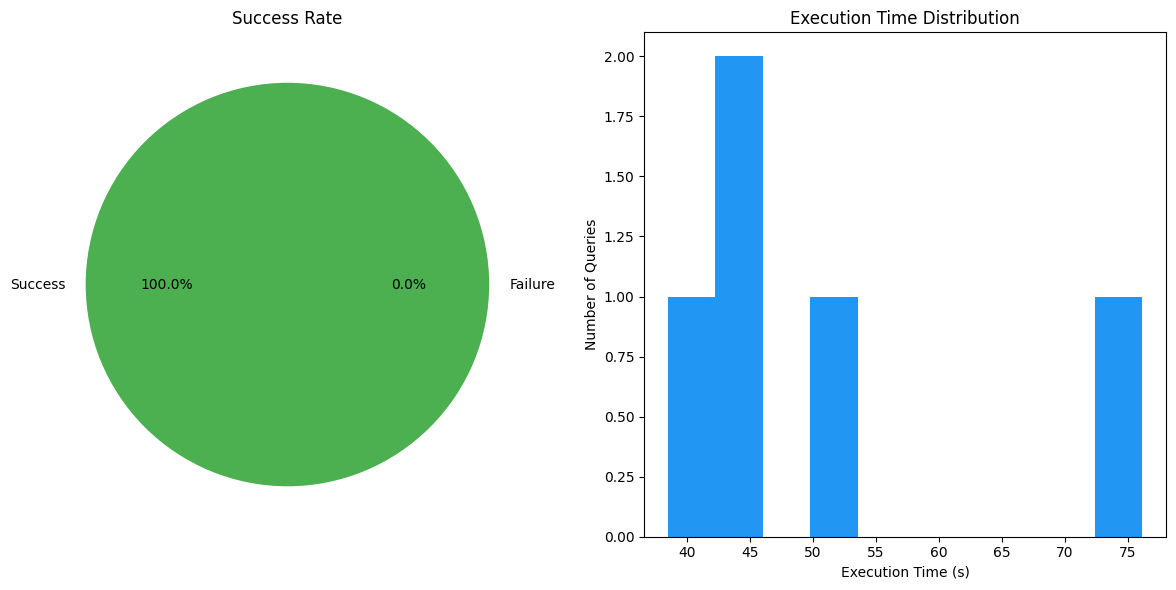


BATCH EVALUATION SUMMARY
Total queries: 5
Success count: 5
Failure count: 0
Success rate: 100.00%
Average execution time: 51.43s
Total execution time: 257.13s

Results have been logged locally.
Batch ID: batch-eval-20250503_101654


,Query,Status,Time (s),Steps
0,What is the current investment outlook for AI ...,✅ success,53.20,3
1,Should I invest in Apple considering their new...,✅ success,38.49,2
2,Compare Tesla and Ford as investment opportuni...,✅ success,45.63,3
3,What's the outlook for big tech stocks given c...,✅ success,43.64,2
4,Is now a good time to invest in healthcare sto...,✅ success,76.18,3


{'batch_id': 'batch-eval-20250503_101654',
 'total_queries': 5,
 'success_count': 5,
 'failure_count': 0,
 'success_rate': 1.0,
 'avg_time': 51.42618064880371,
 'total_time': 257.13090324401855,
 'results': [{'query': 'What is the current investment outlook for AI semiconductor companies?',
   'status': '✅ success',
   'execution_time': 53.19721508026123,
   'steps_completed': 3,
   'result': {'input': 'What is the current investment outlook for AI semiconductor companies?',
    'plan': ['Synthesize the findings from the previous steps to formulate a comprehensive investment outlook for AI semiconductor companies, including potential risks and opportunities.'],
    'past_steps': [('Research the latest quarterly earnings reports of major AI semiconductor companies such as NVIDIA, AMD, and Intel to assess their financial performance and growth projections.',
      "### Step 1: Research Findings on Latest Quarterly Earnings Reports\n\n1. **NVIDIA**:\n   - **Financial Results**: NVIDIA ann

In [82]:
# Function to run batch evaluation
async def run_batch_evaluation(queries, max_time_per_query=120):
    """
    Run a batch evaluation of multiple queries and log results locally
    
    Args:
        queries: List of finance questions to evaluate
        max_time_per_query: Maximum time per query in seconds
    
    Returns:
        Dictionary with summary statistics
    """
    if not local_eval_enabled:
        print("⚠️ Local evaluation is not enabled.")
        return
    
    print(f"Starting batch evaluation of {len(queries)} queries...")
    
    results = []
    success_count = 0
    failure_count = 0
    total_time = 0
    
    # Track batch run with an ID
    batch_id = f"batch-eval-{time.strftime('%Y%m%d_%H%M%S')}"
    
    # Create a progress display
    from IPython.display import display, HTML, clear_output
    import pandas as pd
    
    # Initialize progress table
    progress_df = pd.DataFrame(columns=["Query", "Status", "Time (s)", "Steps"])
    
    # Create a collection for batch results
    batch_results = {
        "id": batch_id,
        "timestamp": time.time(),
        "queries": [],
        "success_rate": 0,
        "total_time": 0
    }
    
    # Process each query
    for i, query in enumerate(queries):
        print(f"\nProcessing query {i+1}/{len(queries)}: {query}")
        start_time = time.time()
        
        try:
            # Run the analysis with reduced verbosity
            result = await run_finance_agent(query, max_time=max_time_per_query)
            
            # Calculate execution time
            exec_time = time.time() - start_time
            total_time += exec_time
            
            # Check if successful
            if "response" in result and result["response"]:
                success_count += 1
                status = "✅ success"
            else:
                failure_count += 1
                status = "❌ failure"
            
            # Log to local evaluation
            evaluation_id = log_evaluation(
                query=query,
                response=result.get("response", ""),
                metadata={
                    "batch_id": batch_id,
                    "query_index": i,
                    "execution_time": exec_time,
                    "status": status,
                    "steps_completed": len(result.get("past_steps", [])),
                    "errors": str(result.get("errors", [])),
                    "evaluation_timestamp": time.time(),
                    "max_time_allowed": max_time_per_query
                }
            )
            
            # Save to batch results
            batch_results["queries"].append({
                "query": query,
                "evaluation_id": evaluation_id,
                "status": status,
                "execution_time": exec_time
            })
            
            # Save result
            results.append({
                "query": query,
                "status": status,
                "execution_time": exec_time,
                "steps_completed": len(result.get("past_steps", [])),
                "result": result
            })
            
            # Update progress table
            progress_df.loc[i] = [
                query[:50] + "..." if len(query) > 50 else query,
                status,
                f"{exec_time:.2f}",
                len(result.get("past_steps", []))
            ]
            
            # Display updated progress
            clear_output(wait=True)
            display(HTML(f"<h3>Batch Evaluation Progress ({i+1}/{len(queries)})</h3>"))
            display(progress_df)
            
            print(f"✅ Query {i+1} completed in {exec_time:.2f}s")
            
        except Exception as e:
            # Handle any errors
            error_time = time.time() - start_time
            total_time += error_time
            failure_count += 1
            
            # Log error to local evaluation
            evaluation_id = log_evaluation(
                query=query,
                response=f"Error: {str(e)}",
                metadata={
                    "batch_id": batch_id,
                    "query_index": i,
                    "execution_time": error_time,
                    "status": "❌ error",
                    "error_message": str(e),
                    "evaluation_timestamp": time.time(),
                    "max_time_allowed": max_time_per_query
                }
            )
            
            # Save to batch results
            batch_results["queries"].append({
                "query": query,
                "evaluation_id": evaluation_id,
                "status": "❌ error",
                "execution_time": error_time
            })
            
            # Save error result
            results.append({
                "query": query,
                "status": "❌ error",
                "execution_time": error_time,
                "error": str(e)
            })
            
            # Update progress table
            progress_df.loc[i] = [
                query[:50] + "..." if len(query) > 50 else query,
                "❌ error",
                f"{error_time:.2f}",
                "N/A"
            ]
            
            # Display updated progress
            clear_output(wait=True)
            display(HTML(f"<h3>Batch Evaluation Progress ({i+1}/{len(queries)})</h3>"))
            display(progress_df)
            
            print(f"❌ Error processing query {i+1}: {str(e)}")
    
    # Calculate summary statistics
    avg_time = total_time / len(queries) if queries else 0
    success_rate = success_count / len(queries) if queries else 0
    
    # Update batch results
    batch_results["success_rate"] = success_rate
    batch_results["total_time"] = total_time
    batch_results["avg_time"] = avg_time
    
    # Store the batch results (for potential future reference)
    if 'evaluation_history' in globals():
        evaluation_history.append({
            "type": "batch",
            "id": batch_id,
            "results": batch_results
        })
    
    # Create summary visualization
    import matplotlib.pyplot as plt
    
    # Prepare final display
    clear_output(wait=True)
    
    # Plot success vs failure
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.pie([success_count, failure_count], 
            labels=['Success', 'Failure'], 
            autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'])
    plt.title('Success Rate')
    
    # Plot execution time distribution
    plt.subplot(1, 2, 2)
    exec_times = [r["execution_time"] for r in results]
    plt.hist(exec_times, bins=10, color='#2196F3')
    plt.xlabel('Execution Time (s)')
    plt.ylabel('Number of Queries')
    plt.title('Execution Time Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*50)
    print("BATCH EVALUATION SUMMARY")
    print("="*50)
    print(f"Total queries: {len(queries)}")
    print(f"Success count: {success_count}")
    print(f"Failure count: {failure_count}")
    print(f"Success rate: {success_rate:.2%}")
    print(f"Average execution time: {avg_time:.2f}s")
    print(f"Total execution time: {total_time:.2f}s")
    print("\nResults have been logged locally.")
    print(f"Batch ID: {batch_id}")
    
    # Display the progress table as final result
    display(progress_df)
    
    return {
        "batch_id": batch_id,
        "total_queries": len(queries),
        "success_count": success_count,
        "failure_count": failure_count,
        "success_rate": success_rate,
        "avg_time": avg_time,
        "total_time": total_time,
        "results": results
    }

# Sample evaluation queries organized by category
finance_evaluation_queries = {
    "stock_analysis": [
        "What is the current investment outlook for AI semiconductor companies?",
        "Should I invest in Apple considering their new product announcements?",
        "Compare Tesla and Ford as investment opportunities in 2025",
        "What's the outlook for big tech stocks given current regulations?",
        "Is now a good time to invest in healthcare stocks?"
    ],
    "market_strategy": [
        "Should I diversify my portfolio amid current market volatility?",
        "How should I adjust my investment strategy given rising interest rates?",
        "What's the best sector to invest in during high inflation?",
        "Is it better to invest in index funds or individual stocks right now?",
        "How should I balance risk in my portfolio given current market conditions?"
    ],
    "alternative_investments": [
        "Is Bitcoin a good investment in the current economic climate?",
        "Compare cryptocurrency and traditional gold as inflation hedges",
        "What's the outlook for real estate investment trusts (REITs)?",
        "Should I consider investing in NFTs as part of a diversified portfolio?",
        "Are green bonds a good investment for environmental impact and returns?"
    ]
}

# Function to run a predefined category evaluation
async def evaluate_category(category_name, max_time_per_query=120):
    """
    Run an evaluation on a predefined category of finance queries
    
    Args:
        category_name: Category name from finance_evaluation_queries
        max_time_per_query: Maximum execution time per query in seconds
    """
    if category_name not in finance_evaluation_queries:
        print(f"❌ Category '{category_name}' not found! Available categories:")
        for cat in finance_evaluation_queries.keys():
            print(f"- {cat}")
        return
    
    queries = finance_evaluation_queries[category_name]
    print(f"Running evaluation for category: {category_name}")
    print(f"Number of queries: {len(queries)}")
    
    return await run_batch_evaluation(queries, max_time_per_query)

# To run an evaluation on a specific category, use:
import asyncio
asyncio.get_event_loop().run_until_complete(evaluate_category("stock_analysis"))

# Utility Tools and Testing

This cell provides utility functions for testing and troubleshooting:

1. **Tavily API Test**: Direct testing of the search API connection
2. **Sample Analysis**: Running a complete analysis with evaluation
3. **Diagnostics**: Tools for verifying component functionality

These utilities help diagnose issues with API connections and verify that all components are functioning correctly.

In [ ]:
# Run a finance analysis with local evaluation enabled
# This will demonstrate the full evaluation integration
analyze_investment("What's the investment outlook for renewable energy companies given current climate policies?", evaluate=True)

In [45]:
# Simple test to verify Tavily API is working
def test_tavily_api():
    """Test the Tavily API connection directly"""
    import os
    from langchain_community.tools.tavily_search import TavilySearchResults
    
    # Get the API key
    tavily_api_key = os.getenv("TAVILY_API_KEY")
    
    # Print key status (without revealing the key)
    if tavily_api_key:
        masked_key = f"{tavily_api_key[:3]}{'*' * (len(tavily_api_key) - 6)}{tavily_api_key[-3:]}"
        print(f"Tavily API key found: {masked_key}")
    else:
        print("Tavily API key not found in environment variables")
        return
        
    # Create search tool instance
    search = TavilySearchResults(max_results=2)
    
    # Test simple search
    try:
        print("\nTesting Tavily API with a simple search query...")
        results = search.invoke("What is the current stock price of Tesla?")
        print("✅ Tavily API is working!\n")
        print("Search Results:")
        for i, result in enumerate(results):
            print(f"\nResult {i+1}:")
            print(f"Title: {result.get('title', 'No title')}")
            print(f"URL: {result.get('url', 'No URL')}")
            content = result.get('content', 'No content')
            print(f"Content snippet: {content[:150]}..." if len(content) > 150 else f"Content snippet: {content}")
    except Exception as e:
        print(f"\n❌ Tavily API test failed with error: {str(e)}")
        print("\nPossible issues:")
        print("1. Invalid API key")
        print("2. API key has expired")
        print("3. Network connectivity issues")
        print("4. Rate limit exceeded")
        print("5. Tavily service is down")

# Uncomment to run the test
# test_tavily_api()